## Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
try:
    import seaborn as sns
except:
    ! pip install seaborn
    import seaborn as sns
try:
    import pyarrow
except:
    ! pip install pyarrow
    import pyarrow

## Helper Classes

In [2]:
class ExploratoryDataAnalysis:
    def __init__(self, str_bucket, str_task_import, str_dirname_output):
        self.str_bucket = str_bucket
        self.str_task_import = str_task_import
        self.str_dirname_output = str_dirname_output

    def import_data(self):
        print('Importing data from S3...')
        str_uri_ratings = f's3://{self.str_bucket}/{self.str_task_import}/ratings.parquet'
        str_uri_users = f's3://{self.str_bucket}/{self.str_task_import}/users.parquet'
        str_uri_movies = f's3://{self.str_bucket}/{self.str_task_import}/movies.parquet'

        self.df_ratings = pd.read_parquet(str_uri_ratings)
        self.df_users = pd.read_parquet(str_uri_users)
        self.df_movies = pd.read_parquet(str_uri_movies)

        # merge into a single dataframe
        self.df_merged = self.df_ratings.merge(
            self.df_users, on='user_id', how='left',
        ).merge(
            self.df_movies, on='movie_id', how='left',
        )
        self.df_merged.sort_values(by='timestamp', ascending=True, inplace=True)
        print(f'  Merged dataset: {self.df_merged.shape[0]:,} rows, {self.df_merged.shape[1]} columns')
        return self

    def get_df_info(self):
        df = self.df_merged
        int_n_ratings = df.shape[0]
        int_n_users = df['user_id'].nunique()
        int_n_movies = df['movie_id'].nunique()
        flt_sparsity = 1 - int_n_ratings / (int_n_users * int_n_movies)

        print(f'Total ratings:     {int_n_ratings:,}')
        print(f'Unique users:      {int_n_users:,}')
        print(f'Unique movies:     {int_n_movies:,}')
        print(f'Rating range:      {df["rating"].min()} - {df["rating"].max()}')
        print(f'Mean rating:       {df["rating"].mean():.2f}')
        print(f'Median rating:     {df["rating"].median():.1f}')
        print(f'Date range:        {df["timestamp"].min()} to {df["timestamp"].max()}')
        print(f'Sparsity:          {flt_sparsity:.4%}')
        print(f'Ratings per user:  {int_n_ratings / int_n_users:.1f} (mean)')
        print(f'Ratings per movie: {int_n_ratings / int_n_movies:.1f} (mean)')
        return self

    def descriptives(self):
        df = self.df_merged
        list_cols = ['rating', 'user_id', 'movie_id']
        list_dict_row = []
        for col in tqdm(list_cols):
            dict_row = {
                'column': col,
                'nan_pct': df[col].isna().mean(),
                'nunique': df[col].nunique(),
                'min': df[col].min(),
                'max': df[col].max(),
                'mean': df[col].mean(),
                'std': df[col].std(),
                'median': df[col].median(),
            }
            list_dict_row.append(dict_row)
        self.df_descriptives = pd.DataFrame(list_dict_row)
        print(self.df_descriptives.to_string(index=False))
        return self

    def plot_rating_distribution(self):
        df = self.df_merged
        df_counts = df['rating'].value_counts().sort_index()

        fig, ax = plt.subplots(figsize=(8, 5))
        bars = ax.bar(df_counts.index.astype(str), df_counts.values, color='tab:blue', edgecolor='black')
        for bar, val in zip(bars, df_counts.values):
            flt_prop = val / df_counts.values.sum()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + df_counts.values.max() * 0.01,
                f'{val:,}\n({flt_prop:.1%})',
                ha='center', va='bottom', fontsize=9,
            )
        ax.set_xlabel('Rating')
        ax.set_ylabel('Count')
        ax.set_title('Rating Distribution', fontsize=14, y=1.02)
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/rating_distribution.png', bbox_inches='tight', dpi=150)
        plt.show()
        return self

    def plot_ratings_over_time(self):
        df = self.df_merged.copy()
        df['year_month'] = df['timestamp'].dt.to_period('M')
        df_monthly = df.groupby('year_month').agg(
            count=('rating', 'count'),
            mean_rating=('rating', 'mean'),
        ).reset_index()
        df_monthly['year_month'] = df_monthly['year_month'].astype(str)

        fig, ax1 = plt.subplots(figsize=(14, 5))
        ax1.bar(range(len(df_monthly)), df_monthly['count'], color='tab:blue', alpha=0.6, label='Rating Count')
        ax1.set_xlabel('Month')
        ax1.set_ylabel('Rating Count', color='tab:blue')
        ax1.tick_params(axis='y', labelcolor='tab:blue')

        # set x-tick labels to every 3rd month
        list_ticks = list(range(0, len(df_monthly), 3))
        ax1.set_xticks(list_ticks)
        ax1.set_xticklabels([df_monthly['year_month'].iloc[i] for i in list_ticks], rotation=45, ha='right')

        ax2 = ax1.twinx()
        ax2.plot(range(len(df_monthly)), df_monthly['mean_rating'], color='tab:red', linewidth=2, label='Mean Rating')
        ax2.set_ylabel('Mean Rating', color='tab:red')
        ax2.tick_params(axis='y', labelcolor='tab:red')

        fig.suptitle('Ratings Over Time', fontsize=14, y=1.02)
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/ratings_over_time.png', bbox_inches='tight', dpi=150)
        plt.show()
        return self

    def plot_user_activity_distribution(self):
        df = self.df_merged
        df_user_counts = df.groupby('user_id')['rating'].count().reset_index()
        df_user_counts.columns = ['user_id', 'n_ratings']

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.hist(df_user_counts['n_ratings'], bins=50, color='tab:blue', edgecolor='black', alpha=0.7)
        ax.set_xlabel('Number of Ratings per User')
        ax.set_ylabel('Number of Users')
        ax.set_title('User Activity Distribution', fontsize=14, y=1.02)
        ax.set_xscale('log')
        ax.axvline(
            x=df_user_counts['n_ratings'].median(),
            color='tab:red', linestyle='--', linewidth=2,
            label=f'Median: {df_user_counts["n_ratings"].median():.0f}',
        )
        ax.legend()
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/user_activity_distribution.png', bbox_inches='tight', dpi=150)
        plt.show()
        return self

    def plot_movie_popularity_distribution(self):
        df = self.df_merged
        df_movie_counts = df.groupby('movie_id')['rating'].count().reset_index()
        df_movie_counts.columns = ['movie_id', 'n_ratings']

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.hist(df_movie_counts['n_ratings'], bins=50, color='tab:orange', edgecolor='black', alpha=0.7)
        ax.set_xlabel('Number of Ratings per Movie')
        ax.set_ylabel('Number of Movies')
        ax.set_title('Movie Popularity Distribution', fontsize=14, y=1.02)
        ax.set_xscale('log')
        ax.axvline(
            x=df_movie_counts['n_ratings'].median(),
            color='tab:red', linestyle='--', linewidth=2,
            label=f'Median: {df_movie_counts["n_ratings"].median():.0f}',
        )
        ax.legend()
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/movie_popularity_distribution.png', bbox_inches='tight', dpi=150)
        plt.show()
        return self

    def plot_genre_analysis(self):
        df = self.df_merged.copy()
        # split multi-genre strings
        df_genres = df.assign(genre=df['genres'].str.split('|')).explode('genre')

        # genre frequency
        df_genre_counts = df_genres.groupby('genre').agg(
            count=('rating', 'count'),
            mean_rating=('rating', 'mean'),
        ).reset_index()
        df_genre_counts.sort_values(by='count', ascending=True, inplace=True)

        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        fig.suptitle('Genre Analysis', fontsize=14, y=1.02)

        # genre frequency
        axes[0].barh(df_genre_counts['genre'], df_genre_counts['count'], color='tab:blue', edgecolor='black')
        axes[0].set_xlabel('Number of Ratings')
        axes[0].set_title('Ratings by Genre')

        # mean rating by genre
        df_genre_counts_sorted = df_genre_counts.sort_values(by='mean_rating', ascending=True)
        colors = ['tab:red' if r < df['rating'].mean() else 'tab:green' for r in df_genre_counts_sorted['mean_rating']]
        axes[1].barh(df_genre_counts_sorted['genre'], df_genre_counts_sorted['mean_rating'], color=colors, edgecolor='black')
        axes[1].axvline(x=df['rating'].mean(), color='black', linestyle='--', linewidth=1, label=f'Overall Mean: {df["rating"].mean():.2f}')
        axes[1].set_xlabel('Mean Rating')
        axes[1].set_title('Mean Rating by Genre')
        axes[1].legend()

        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/genre_analysis.png', bbox_inches='tight', dpi=150)
        plt.show()
        return self

    def plot_demographic_analysis(self):
        df = self.df_merged

        # age group mapping from MovieLens README
        dict_age_map = {
            1: 'Under 18', 18: '18-24', 25: '25-34',
            35: '35-44', 45: '45-49', 50: '50-55', 56: '56+',
        }
        df_demo = df.copy()
        df_demo['age_group'] = df_demo['age'].map(dict_age_map)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle('Demographic Analysis', fontsize=14, y=1.02)

        # rating distribution by gender
        for str_gender, str_label in [('M', 'Male'), ('F', 'Female')]:
            df_g = df_demo[df_demo['gender'] == str_gender]
            axes[0].hist(df_g['rating'], bins=5, alpha=0.5, label=f'{str_label} (N={len(df_g):,})', density=True)
        axes[0].set_xlabel('Rating')
        axes[0].set_ylabel('Density')
        axes[0].set_title('Rating Distribution by Gender')
        axes[0].legend()

        # mean rating by age group
        list_age_order = ['Under 18', '18-24', '25-34', '35-44', '45-49', '50-55', '56+']
        df_age_rating = df_demo.groupby('age_group')['rating'].mean().reindex(list_age_order)
        axes[1].bar(df_age_rating.index, df_age_rating.values, color='tab:green', edgecolor='black')
        axes[1].set_xlabel('Age Group')
        axes[1].set_ylabel('Mean Rating')
        axes[1].set_title('Mean Rating by Age Group')
        axes[1].tick_params(axis='x', rotation=45)

        # ratings count by age group
        df_age_count = df_demo.groupby('age_group')['rating'].count().reindex(list_age_order)
        axes[2].bar(df_age_count.index, df_age_count.values, color='tab:purple', edgecolor='black')
        axes[2].set_xlabel('Age Group')
        axes[2].set_ylabel('Number of Ratings')
        axes[2].set_title('Rating Volume by Age Group')
        axes[2].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/demographic_analysis.png', bbox_inches='tight', dpi=150)
        plt.show()
        return self

    def plot_interaction_heatmap(self):
        df = self.df_merged

        # get top 20 most active users and top 20 most rated movies
        list_top_users = df['user_id'].value_counts().head(20).index.tolist()
        list_top_movies = df['movie_id'].value_counts().head(20).index.tolist()

        df_sub = df[(df['user_id'].isin(list_top_users)) & (df['movie_id'].isin(list_top_movies))]
        df_pivot = df_sub.pivot_table(index='user_id', columns='movie_id', values='rating')

        # get movie titles for column labels
        dict_movie_titles = dict(zip(self.df_movies['movie_id'], self.df_movies['title']))
        list_col_labels = [dict_movie_titles.get(m, str(m))[:20] for m in df_pivot.columns]

        fig, ax = plt.subplots(figsize=(14, 8))
        sns.heatmap(
            df_pivot,
            cmap='YlOrRd',
            center=3,
            annot=True,
            fmt='.0f',
            xticklabels=list_col_labels,
            ax=ax,
            cbar_kws={'label': 'Rating'},
        )
        ax.set_xlabel('Movie')
        ax.set_ylabel('User ID')
        ax.set_title('User-Movie Interaction Heatmap (Top 20 Users x Top 20 Movies)', fontsize=14, y=1.02)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/interaction_heatmap.png', bbox_inches='tight', dpi=150)
        plt.show()
        return self

## Constants

In [3]:
str_bucket = 'recommender-system-demo'
str_task = '01_eda'
str_task_import = '00_data_collection'
str_dirname_output = './output'

## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

## Initialize EDA Class

In [5]:
cls_eda = ExploratoryDataAnalysis(
    str_bucket=str_bucket,
    str_task_import=str_task_import,
    str_dirname_output=str_dirname_output,
)

## Import Data

In [6]:
cls_eda.import_data()

Importing data from S3...
  Merged dataset: 1,000,209 rows, 10 columns


## Dataset Summary

In [7]:
cls_eda.get_df_info()

Total ratings:     1,000,209
Unique users:      6,040
Unique movies:     3,706
Rating range:      1 - 5
Mean rating:       3.58
Median rating:     4.0
Date range:        2000-04-25 23:05:32 to 2003-02-28 17:49:50
Sparsity:          95.5316%
Ratings per user:  165.6 (mean)
Ratings per movie: 269.9 (mean)


## Descriptive Statistics

In [8]:
cls_eda.descriptives()

100%|██████████| 3/3 [00:00<00:00, 31.45it/s]

  column  nan_pct  nunique  min  max        mean         std  median
  rating      0.0        5    1    5    3.581564    1.117102     4.0
 user_id      0.0     6040    1 6040 3024.512348 1728.412695  3070.0
movie_id      0.0     3706    1 3952 1865.539898 1096.040689  1835.0


## Rating Distribution

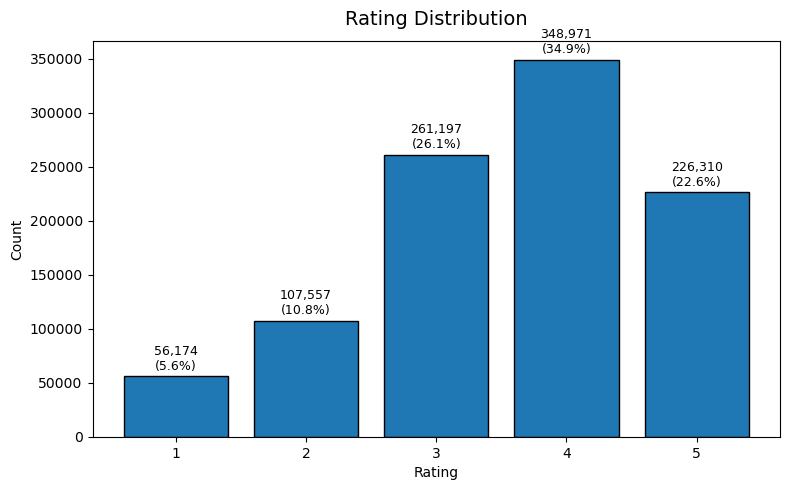

In [9]:
cls_eda.plot_rating_distribution()

## Ratings Over Time

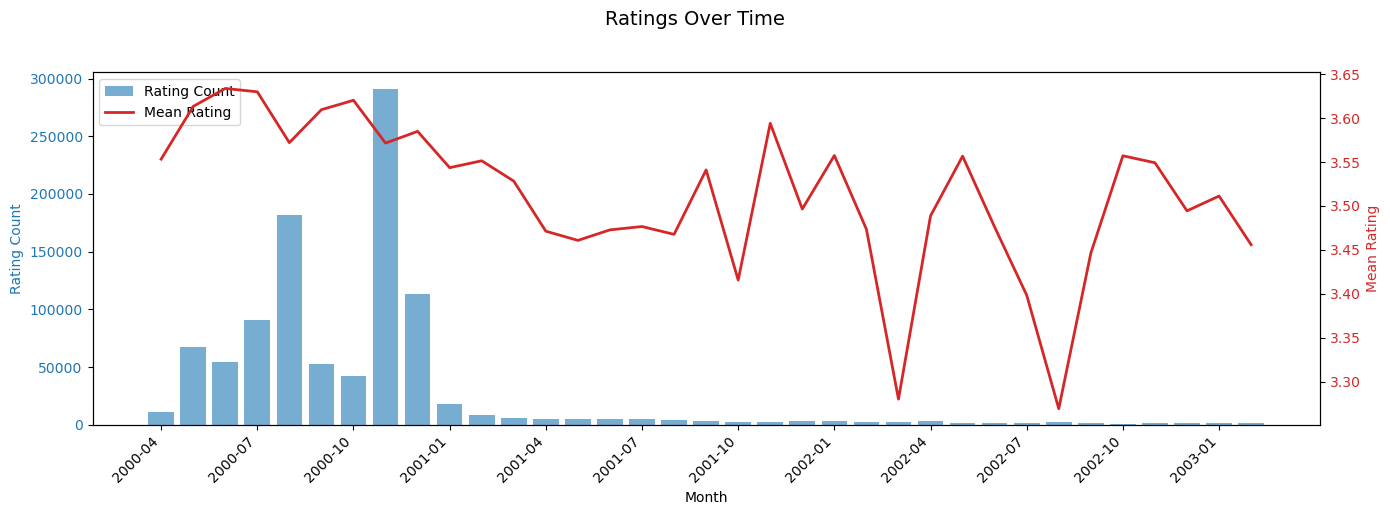

In [10]:
cls_eda.plot_ratings_over_time()

## User Activity Distribution

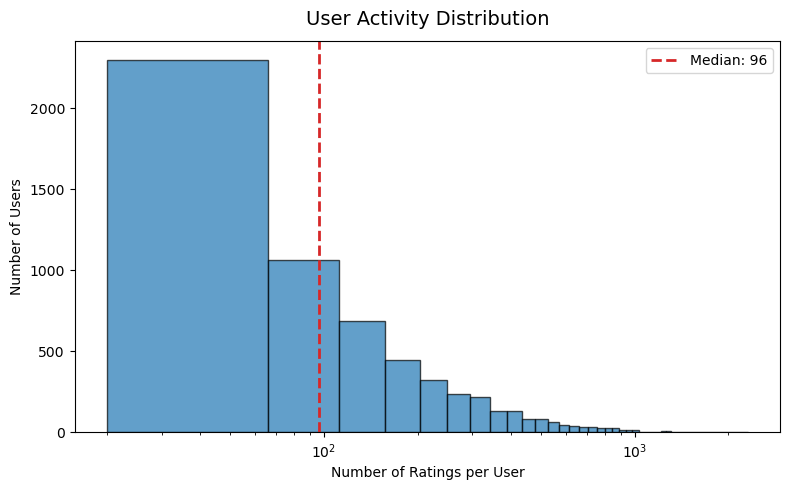

In [11]:
cls_eda.plot_user_activity_distribution()

## Movie Popularity Distribution

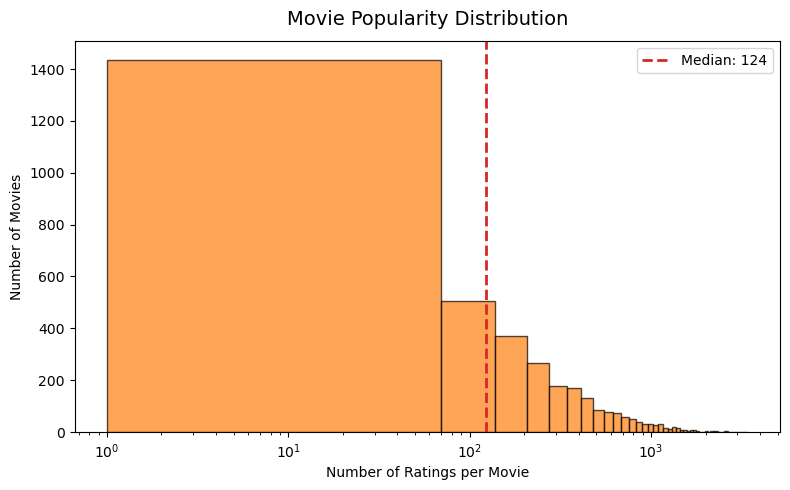

In [12]:
cls_eda.plot_movie_popularity_distribution()

## Genre Analysis

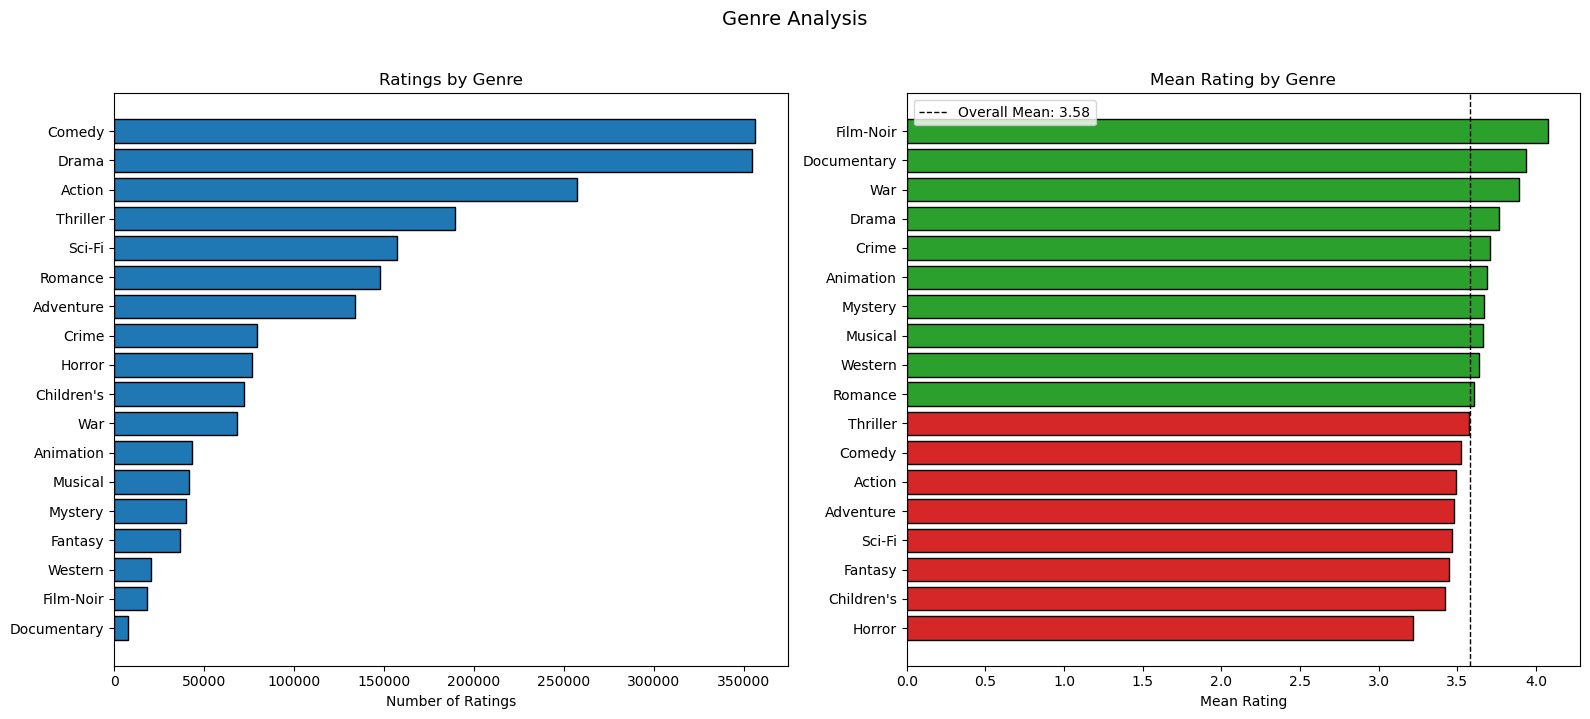

In [13]:
cls_eda.plot_genre_analysis()

## Demographic Analysis

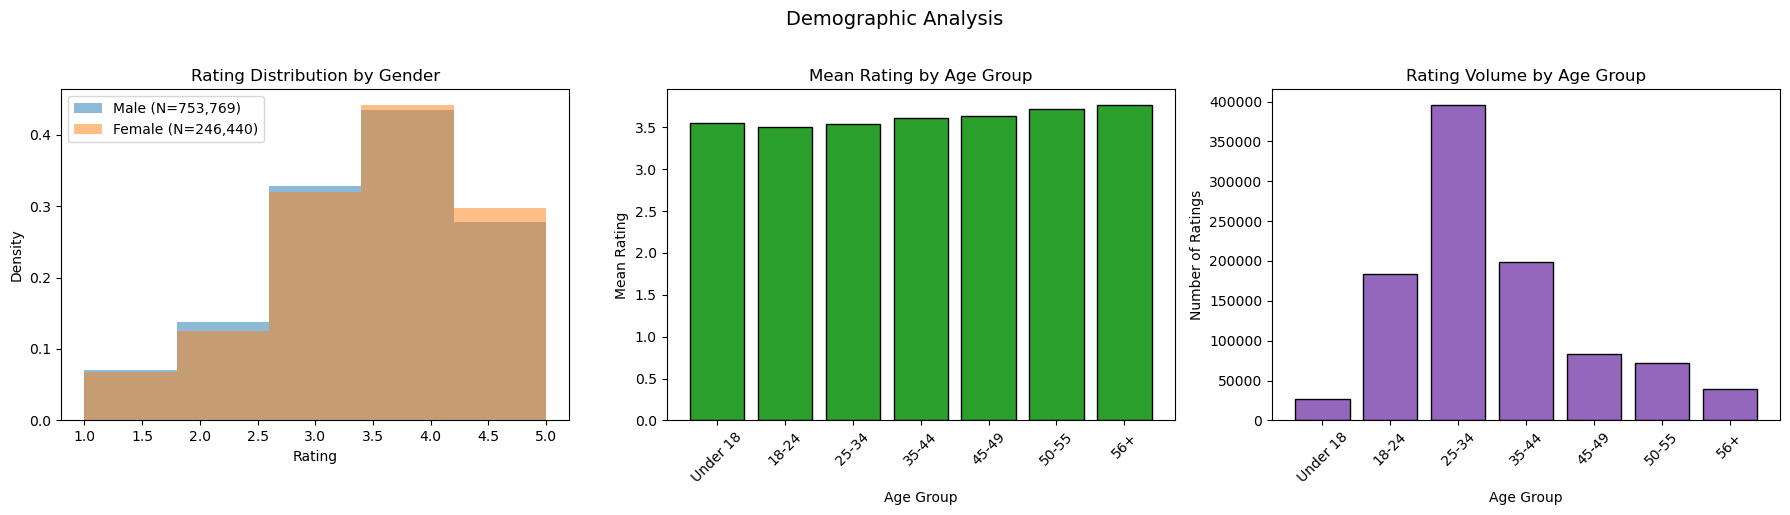

In [14]:
cls_eda.plot_demographic_analysis()

## User-Movie Interaction Heatmap

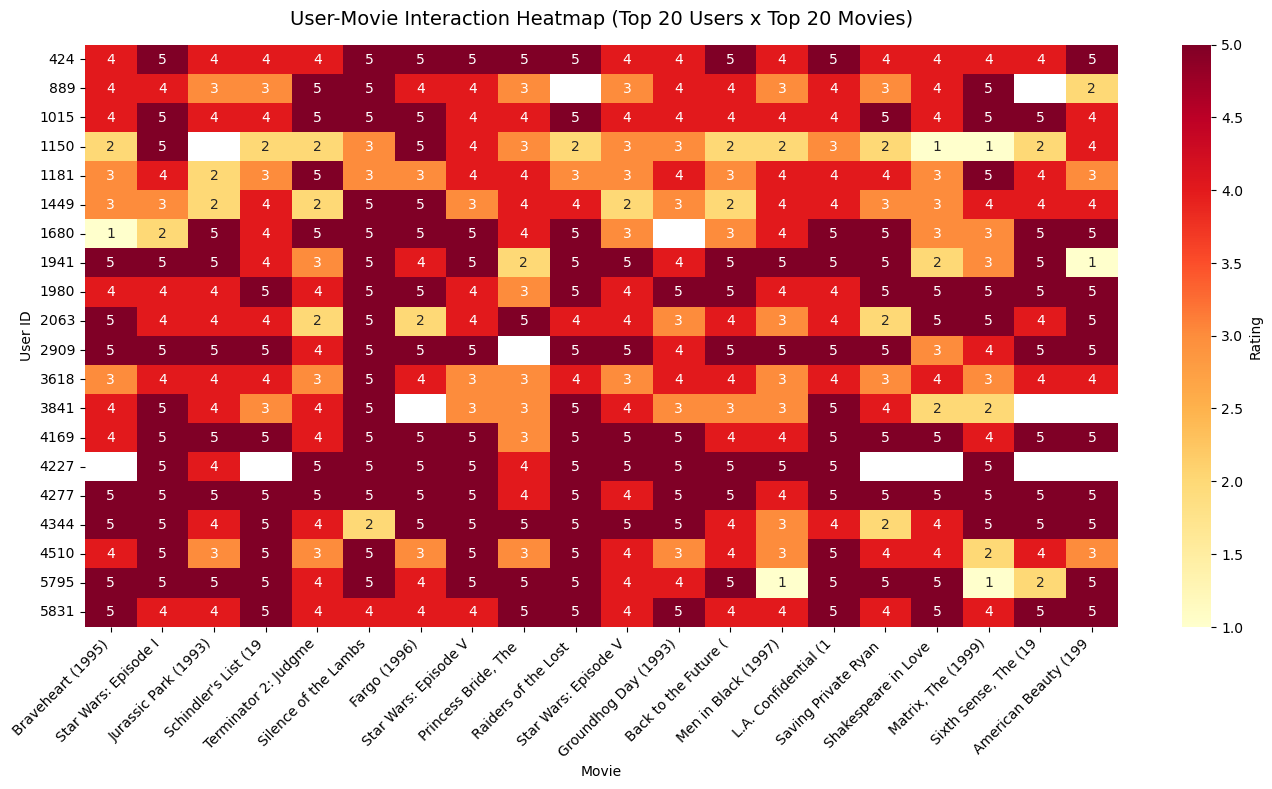

In [15]:
cls_eda.plot_interaction_heatmap()